# 🚇 Predicción de Demanda — Subway de Nueva York (2025)
**Pipeline completo: carga → limpieza → enriquecimiento → BiLSTM → métricas**

Universidad de San Buenaventura Cali — Proyecto Deep Learning


## 0. Instalación y configuración

In [ ]:
!pip install openmeteo-requests requests-cache retry-requests --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.0/211.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.5/772.5 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 70.5 MB/s eta 0:00:00


In [ ]:
import os, math, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import requests_cache
from retry_requests import retry

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")


TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Google Drive y rutas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE   = '/content/drive/MyDrive/TransitDemand'
PATH_HOURLY  = os.path.join(DRIVE_BASE, 'MTA_Subway_Hourly_Ridership_2025.csv')
PATH_MODELS  = os.path.join(DRIVE_BASE, 'models')
PATH_RESULTS = os.path.join(DRIVE_BASE, 'results')

os.makedirs(PATH_MODELS,  exist_ok=True)
os.makedirs(PATH_RESULTS, exist_ok=True)

print("Rutas configuradas:")
print(f"  Dataset    : {PATH_HOURLY}")
print(f"  Modelos    : {PATH_MODELS}")
print(f"  Resultados : {PATH_RESULTS}")


Mounted at /content/drive
Rutas configuradas:
  Dataset    : /content/drive/MyDrive/TransitDemand/MTA_Subway_Hourly_Ridership_2025.csv
  Modelos    : /content/drive/MyDrive/TransitDemand/models
  Resultados : /content/drive/MyDrive/TransitDemand/results


## 2. Carga y limpieza inicial del dataset

El dataset ya viene filtrado por subway + Full Fare en origen.
Se optimizan los dtypes categóricos y las columnas numéricas se convierten
con `pd.to_numeric` para tolerar valores corruptos.


In [ ]:
DTYPE_MAP = {
    'transit_mode'        : 'category',
    'station_complex_id'  : 'category',   # contiene IDs como 'TRAM1'
    'station_complex'     : 'category',
    'borough'             : 'category',
    'payment_method'      : 'category',
    'fare_class_category' : 'category',
}

print("Cargando dataset principal...")
df_raw = pd.read_csv(PATH_HOURLY, dtype=DTYPE_MAP, low_memory=False)
print(f"Filas cargadas : {df_raw.shape[0]:,}")

# Conversión segura de columnas numéricas
for col in ['ridership', 'transfers', 'latitude', 'longitude']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Parsear timestamp
df_raw['transit_timestamp'] = pd.to_datetime(
    df_raw['transit_timestamp'], errors='coerce'
)

# Eliminar filas inválidas
df_raw.dropna(subset=['transit_timestamp', 'ridership'], inplace=True)

print(f"Filas válidas  : {df_raw.shape[0]:,}")
print(f"RAM estimada   : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Cargando dataset principal...
Filas cargadas : 6,570,508
Filas válidas  : 6,398,961
RAM estimada   : 842.5 MB


## 3. Agregación MetroCard + OMNY

El dataset tiene una fila por método de pago para cada estación × hora.
Se suman ambas para obtener el total de pasajeros por estación y franja horaria.


In [ ]:
GROUP_COLS = ['transit_timestamp', 'station_complex_id',
              'station_complex', 'borough']

df = (
    df_raw
    .groupby(GROUP_COLS, observed=True)
    .agg(ridership=('ridership', 'sum'),
         transfers=('transfers',  'sum'))
    .reset_index()
)

df['datetime'] = pd.to_datetime(df['transit_timestamp'])
df['date']     = df['datetime'].dt.date
df['hour']     = df['datetime'].dt.hour

print(f"Filas tras agregación: {len(df):,}")
print(f"Rango temporal       : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Estaciones únicas    : {df['station_complex_id'].nunique()}")

# Liberar memoria de df_raw
del df_raw


Filas tras agregación: 3,625,045
Rango temporal       : 2025-01-01 01:00:00 → 2025-12-31 23:00:00
Estaciones únicas    : 428


## 4. Limpieza de estaciones con datos insuficientes o irregulares

Se eliminan estaciones con muy pocos registros (probablemente nuevas o con
fallos de reporte) para evitar entrenar con series fragmentadas.


In [ ]:
# Conteo de registros por estación
counts = df['station_complex_id'].value_counts()
print("Distribución de registros por estación:")
print(counts.describe())
print(f"\nEstaciones con menos de 8.000 registros: {(counts < 8000).sum()}")
print(f"Estaciones con menos de 5.000 registros: {(counts < 5000).sum()}")


Distribución de registros por estación:
count     428.000000
mean     8469.731308
std       562.695603
min      4557.000000
25%      8430.750000
50%      8641.000000
75%      8730.250000
max      8759.000000
Name: count, dtype: float64

Estaciones con menos de 8.000 registros: 29
Estaciones con menos de 5.000 registros: 2


In [ ]:
# Filtrar estaciones con al menos MIN_REGISTROS observaciones
# (umbral conservador: una estación con datos completos tiene ~8.760 horas/año)
MIN_REGISTROS = 8000
estaciones_validas = counts[counts >= MIN_REGISTROS].index

df = df[df['station_complex_id'].isin(estaciones_validas)].copy()
df['station_complex_id'] = df['station_complex_id'].cat.remove_unused_categories()
df['station_complex']    = df['station_complex'].cat.remove_unused_categories()

print(f"Estaciones conservadas: {df['station_complex_id'].nunique()}")
print(f"Filas después del filtro: {len(df):,}")


Estaciones conservadas: 399
Filas después del filtro: 3,426,049


## 5. Enriquecimiento climático — Open-Meteo Historical Weather API

Datos horarios para NYC durante 2025. Sin API key, licencia CC BY 4.0.


In [ ]:
cache_session  = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session  = retry(cache_session, retries=5, backoff_factor=0.2)

resp = retry_session.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude"   : 40.7128,
        "longitude"  : -74.0060,
        "start_date" : "2025-01-01",
        "end_date"   : "2025-12-31",
        "hourly"     : ["temperature_2m", "precipitation",
                        "relative_humidity_2m", "wind_speed_10m",
                        "weather_code"],
        "timezone"   : "America/New_York"
    }
)
resp.raise_for_status()
wj = resp.json()

df_weather = pd.DataFrame({
    'datetime'             : pd.to_datetime(wj['hourly']['time']),
    'temperature_2m'       : wj['hourly']['temperature_2m'],
    'precipitation'        : wj['hourly']['precipitation'],
    'relative_humidity_2m' : wj['hourly']['relative_humidity_2m'],
    'wind_speed_10m'       : wj['hourly']['wind_speed_10m'],
    'weather_code'         : wj['hourly']['weather_code'],
})
df_weather['datetime'] = df_weather['datetime'].dt.floor('H')
df_weather = df_weather.sort_values('datetime').reset_index(drop=True)

print(f"Registros climáticos: {len(df_weather):,}")
df_weather.head(3)


Registros climáticos: 8,760


,datetime,temperature_2m,precipitation,relative_humidity_2m,wind_speed_10m,weather_code
0,2025-01-01 00:00:00,8.1,3.4,93,17.5,63
1,2025-01-01 01:00:00,9.1,0.9,95,12.4,53
2,2025-01-01 02:00:00,8.6,0.0,98,5.0,3


## 6. Festivos NYC 2025

In [ ]:
from datetime import date

NYC_HOLIDAYS_2025 = {
    date(2025,  1,  1),  date(2025,  1, 20),  date(2025,  2, 12),
    date(2025,  2, 17),  date(2025,  5, 26),  date(2025,  6, 19),
    date(2025,  7,  4),  date(2025,  9,  1),  date(2025, 10, 13),
    date(2025, 11, 11),  date(2025, 11, 27),  date(2025, 12, 25),
}

df['is_holiday'] = df['date'].apply(lambda d: int(d in NYC_HOLIDAYS_2025))
print(f"Registros con festivo=1: {df['is_holiday'].sum():,}")


Registros con festivo=1: 112,748


## 7. Ingeniería de características

- **Merge climático** por hora exacta (asof con tolerancia de 1 h)
- **Codificación cíclica** de hora, día de la semana y mes
- **Lags** de 24 h y 168 h por estación
- **`ridership_norm`**: z-score por estación para que el modelo aprenda
  patrones relativos (la red opera sobre escala normalizada por estación,
  pero conservamos `ridership` original para reportar métricas en pasajeros).


In [ ]:
# Merge con clima (ordenado por datetime, reset de índices)
df = df.sort_values('datetime').reset_index(drop=True)
df_weather_sorted = df_weather.sort_values('datetime').reset_index(drop=True)

df = pd.merge_asof(
    df, df_weather_sorted,
    on='datetime',
    direction='nearest',
    tolerance=pd.Timedelta('1H')
)

# Verificación
n_sin_clima = df['temperature_2m'].isna().sum()
print(f"Filas sin clima asignado: {n_sin_clima:,}")
df = df.dropna(subset=['temperature_2m']).reset_index(drop=True)
print(f"Filas tras merge climático: {len(df):,}")


Filas sin clima asignado: 0
Filas tras merge climático: 3,426,049


In [ ]:
# Variables temporales cíclicas
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype('int8')
df['month']       = df['datetime'].dt.month

df['hour_sin']  = np.sin(2 * np.pi * df['hour']        / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']        / 24)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']       / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']       / 12)

print("Variables temporales creadas")


Variables temporales creadas


In [ ]:
# Normalización por estación (z-score)
# Guardamos media y std por estación para poder DESNORMALIZAR al evaluar
station_stats = df.groupby('station_complex_id')['ridership'].agg(['mean', 'std'])
station_stats.columns = ['rid_mean', 'rid_std']
# Evitar división por cero en estaciones con std=0
station_stats['rid_std'] = station_stats['rid_std'].replace(0, 1)

df = df.merge(station_stats, left_on='station_complex_id',
              right_index=True, how='left')
df['ridership_norm'] = (df['ridership'] - df['rid_mean']) / df['rid_std']

print(f"Estadísticos por estación calculados: {len(station_stats)} estaciones")
print("Muestra:")
print(station_stats.head(3))


Estadísticos por estación calculados: 399 estaciones
Muestra:
                      rid_mean     rid_std
station_complex_id                        
1                   255.760480  214.979097
10                  364.123346  327.410637
100                  58.729112   48.720019


In [ ]:
# ── Lags de demanda por estación (sobre la versión normalizada) ──────────
df = df.sort_values(['station_complex_id', 'datetime']).reset_index(drop=True)

df['ridership_lag_24h']  = df.groupby('station_complex_id', observed=True)['ridership_norm'].shift(24)
df['ridership_lag_168h'] = df.groupby('station_complex_id', observed=True)['ridership_norm'].shift(168)

# Eliminar las primeras 168h por estación (no tienen lag completo)
n_antes = len(df)
df = df.dropna(subset=['ridership_lag_24h', 'ridership_lag_168h']).reset_index(drop=True)
print(f"Filas eliminadas por lags: {n_antes - len(df):,}")
print(f"Dataset final enriquecido : {len(df):,} filas × {df.shape[1]} columnas")


Filas eliminadas por lags: 67,032
Dataset final enriquecido : 3,359,017 filas × 29 columnas


In [ ]:
df.head(10)

,transit_timestamp,station_complex_id,station_complex,borough,ridership,transfers,datetime,date,hour,is_holiday,...,hour_cos,dow_sin,dow_cos,month_sin,month_cos,rid_mean,rid_std,ridership_norm,ridership_lag_24h,ridership_lag_168h
0,2025-01-08 01:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,11.0,0.0,2025-01-08 01:00:00,2025-01-08,1,0,...,9.659258e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,-1.138532,-1.138532,-0.812918
1,2025-01-08 02:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,5.0,0.0,2025-01-08 02:00:00,2025-01-08,2,0,...,8.660254e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,-1.166441,-1.157138,-0.998983
2,2025-01-08 03:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,13.0,0.0,2025-01-08 03:00:00,2025-01-08,3,0,...,7.071068e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,-1.129228,-1.133880,-1.082712
3,2025-01-08 04:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,34.0,0.0,2025-01-08 04:00:00,2025-01-08,4,0,...,5.000000e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,-1.031544,-1.012938,-1.110622
4,2025-01-08 05:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,158.0,9.0,2025-01-08 05:00:00,2025-01-08,5,0,...,2.588190e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,-0.454744,-0.426834,-1.050151
5,2025-01-08 06:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,486.0,70.0,2025-01-08 06:00:00,2025-01-08,6,0,...,6.123234e-17,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,1.070986,0.996560,-0.961770
6,2025-01-08 07:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,983.0,89.0,2025-01-08 07:00:00,2025-01-08,7,0,...,-2.588190e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,3.382838,3.889864,-0.840828
7,2025-01-08 08:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,182.0,20.0,2025-01-08 08:00:00,2025-01-08,8,0,...,-5.000000e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,-0.343105,-0.398925,-0.715235
8,2025-01-08 09:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,824.0,61.0,2025-01-08 09:00:00,2025-01-08,9,0,...,-7.071068e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,2.643231,2.624625,-0.459396
9,2025-01-08 10:00:00,1,"Astoria-Ditmars Blvd (N,W)",Queens,418.0,27.0,2025-01-08 10:00:00,2025-01-08,10,0,...,-8.660254e-01,0.974928,-0.222521,0.5,0.866025,255.76048,214.979097,0.754676,0.684902,-0.491957


## 8. Análisis Exploratorio (EDA)

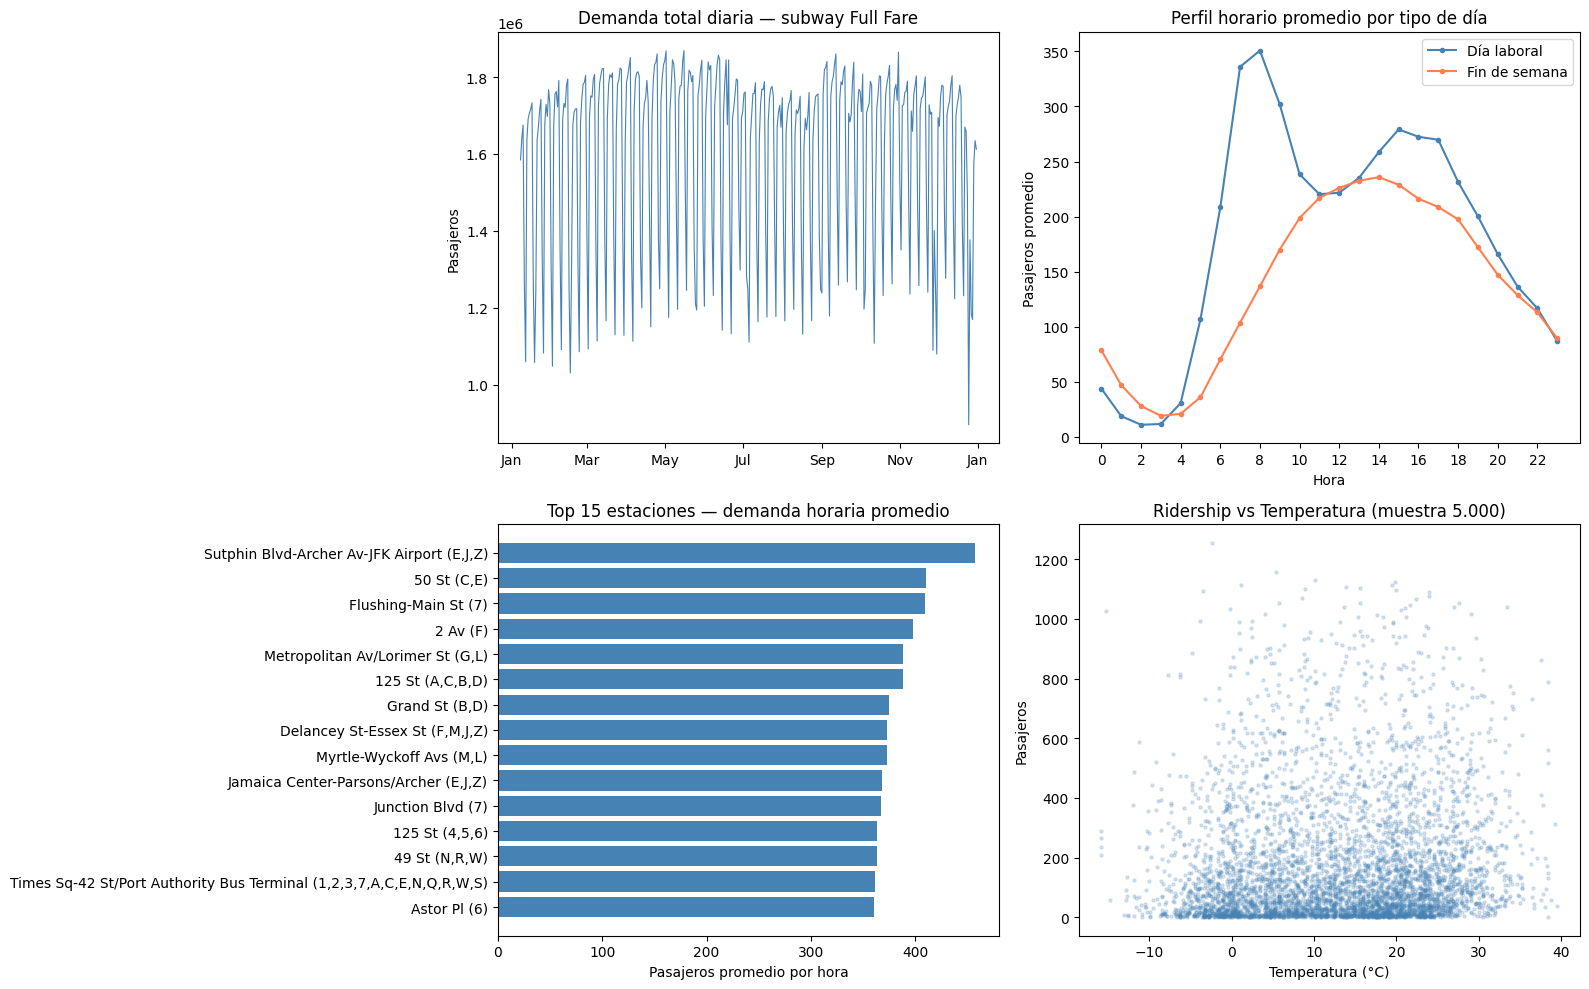

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Serie diaria total
daily_total = df.groupby('date')['ridership'].sum().reset_index()
daily_total['date'] = pd.to_datetime(daily_total['date'])
axes[0, 0].plot(daily_total['date'], daily_total['ridership'],
                linewidth=0.8, color='steelblue')
axes[0, 0].set_title('Demanda total diaria — subway Full Fare')
axes[0, 0].set_ylabel('Pasajeros')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Perfil horario laboral vs fin de semana
hp = df.groupby(['hour', 'is_weekend'])['ridership'].mean().reset_index()
for val, label, color in [(0, 'Día laboral', 'steelblue'),
                           (1, 'Fin de semana', 'coral')]:
    sub = hp[hp['is_weekend'] == val]
    axes[0, 1].plot(sub['hour'], sub['ridership'], label=label,
                    color=color, marker='o', markersize=3)
axes[0, 1].set_title('Perfil horario promedio por tipo de día')
axes[0, 1].set_xlabel('Hora')
axes[0, 1].set_ylabel('Pasajeros promedio')
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].legend()

# Top 15 estaciones
top = (df.groupby('station_complex', observed=True)['ridership']
         .mean().nlargest(15).reset_index())
axes[1, 0].barh(top['station_complex'][::-1],
                top['ridership'][::-1], color='steelblue')
axes[1, 0].set_title('Top 15 estaciones — demanda horaria promedio')
axes[1, 0].set_xlabel('Pasajeros promedio por hora')

# Ridership vs temperatura (muestra)
sample = df.sample(min(5000, len(df)), random_state=SEED)
axes[1, 1].scatter(sample['temperature_2m'], sample['ridership'],
                   alpha=0.2, s=5, color='steelblue')
axes[1, 1].set_title('Ridership vs Temperatura (muestra 5.000)')
axes[1, 1].set_xlabel('Temperatura (°C)')
axes[1, 1].set_ylabel('Pasajeros')

plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'eda_overview.png'), dpi=150)
plt.show()


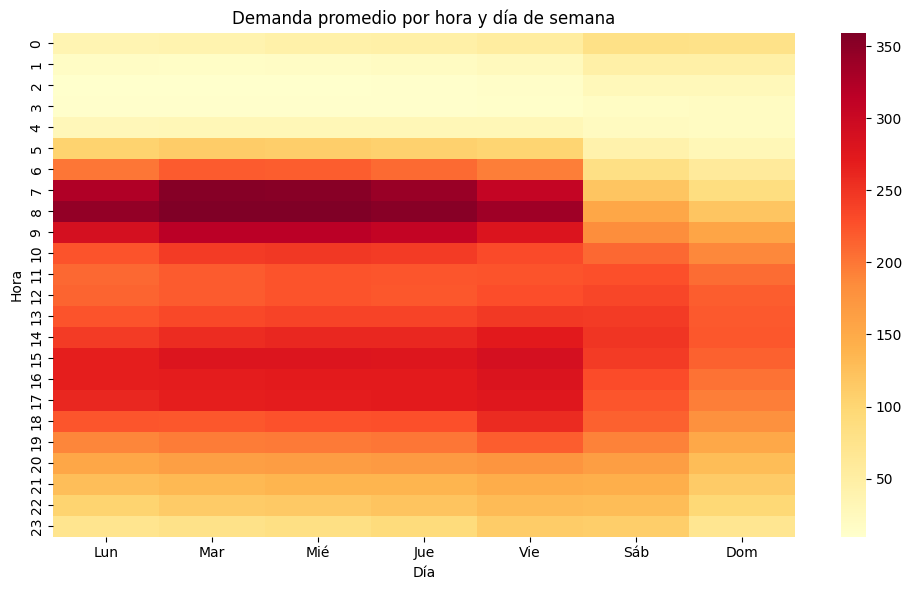

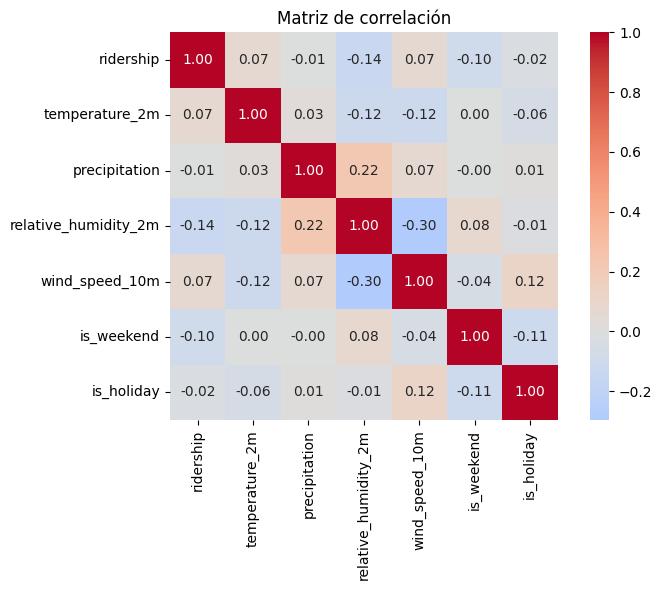

In [ ]:
# Heatmap hora × día
pivot = df.groupby(['hour', 'day_of_week'])['ridership'].mean().unstack()
pivot.columns = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax)
ax.set_title('Demanda promedio por hora y día de semana')
ax.set_xlabel('Día'); ax.set_ylabel('Hora')
plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'heatmap_semanal.png'), dpi=150)
plt.show()

# Matriz de correlación
CORR_COLS = ['ridership', 'temperature_2m', 'precipitation',
             'relative_humidity_2m', 'wind_speed_10m',
             'is_weekend', 'is_holiday']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[CORR_COLS].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'correlacion.png'), dpi=150)
plt.show()


## 9. Selección de estación piloto y preparación del dataset

Se selecciona una estación de **demanda media** como caso piloto representativo
(no la de mayor volumen, para evitar resultados sesgados a outliers de tráfico).


In [ ]:
# Estación de demanda media (mediana del ranking)
ranked = df.groupby('station_complex_id', observed=True)['ridership'].mean().sort_values()
PILOT_ID = ranked.index[len(ranked) // 2]
PILOT_NAME = df.loc[df['station_complex_id'] == PILOT_ID, 'station_complex'].iloc[0]

print(f"Estación piloto: {PILOT_NAME}  (ID: {PILOT_ID})")
print(f"  Demanda promedio horaria: {ranked.loc[PILOT_ID]:,.0f} pasajeros")

df_pilot = (
    df[df['station_complex_id'] == PILOT_ID]
    .sort_values('datetime')
    .reset_index(drop=True)
)
print(f"  Registros: {len(df_pilot):,}")

# Recuperar mean/std de la estación piloto para desnormalizar más adelante
PILOT_MEAN = station_stats.loc[PILOT_ID, 'rid_mean']
PILOT_STD  = station_stats.loc[PILOT_ID, 'rid_std']
print(f"  Mean ridership: {PILOT_MEAN:,.2f} | Std: {PILOT_STD:,.2f}")


Estación piloto: 110 St-Malcolm X Plaza (2,3)  (ID: 441)
  Demanda promedio horaria: 137 pasajeros
  Registros: 8,520
  Mean ridership: 136.32 | Std: 113.26


In [ ]:
# ── Definición de features y target ──────────────────────────────────────
FEAT_WEATHER = [
    'ridership_lag_24h', 'ridership_lag_168h',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'is_weekend', 'is_holiday',
    'temperature_2m', 'precipitation',
    'relative_humidity_2m', 'wind_speed_10m'
]
FEAT_NO_WEATHER = [f for f in FEAT_WEATHER
                   if f not in ['temperature_2m', 'precipitation',
                                'relative_humidity_2m', 'wind_speed_10m']]
TARGET = 'ridership_norm'   # entrenamos con la versión normalizada por estación

# Limpieza final (por si quedó algún NaN)
df_pilot = df_pilot.dropna(subset=FEAT_WEATHER + [TARGET]).reset_index(drop=True)
print(f"Filas válidas en estación piloto: {len(df_pilot):,}")


Filas válidas en estación piloto: 8,520


In [ ]:
# ── Partición temporal cronológica ───────────────────────────────────────
N       = len(df_pilot)
N_TRAIN = int(N * 0.70)
N_VAL   = int(N * 0.15)

train_df = df_pilot.iloc[:N_TRAIN].copy()
val_df   = df_pilot.iloc[N_TRAIN : N_TRAIN + N_VAL].copy()
test_df  = df_pilot.iloc[N_TRAIN + N_VAL:].copy()

print(f"Train : {len(train_df):,}  |  {train_df['datetime'].min().date()} → {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):,}  |  {val_df['datetime'].min().date()} → {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):,}  |  {test_df['datetime'].min().date()} → {test_df['datetime'].max().date()}")


Train : 5,964  |  2025-01-08 → 2025-09-16
Val   : 1,278  |  2025-09-16 → 2025-11-08
Test  : 1,278  |  2025-11-08 → 2025-12-31


In [ ]:
# ── Escalado de features (target ya normalizado por estación) ────────────
scaler_X = StandardScaler()
X_tr_sc = scaler_X.fit_transform(train_df[FEAT_WEATHER])
X_vl_sc = scaler_X.transform(val_df[FEAT_WEATHER])
X_te_sc = scaler_X.transform(test_df[FEAT_WEATHER])

y_tr_sc = train_df[TARGET].values.astype(np.float32)
y_vl_sc = val_df[TARGET].values.astype(np.float32)
y_te_sc = test_df[TARGET].values.astype(np.float32)

print("Scaling aplicado ✓")
print(f"  X shape (train): {X_tr_sc.shape}")
print(f"  y shape (train): {y_tr_sc.shape}")


Scaling aplicado ✓
  X shape (train): (5964, 14)
  y shape (train): (5964,)


In [ ]:
# ── Ventanas deslizantes ─────────────────────────────────────────────────
T = 48   # ventana de contexto: 48 horas (2 días)
H = 1    # horizonte: 1 hora adelante

def make_sequences(X, y, window=T, horizon=H):
    Xs, ys = [], []
    for i in range(len(X) - window - horizon + 1):
        Xs.append(X[i : i + window])
        ys.append(y[i + window + horizon - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_tr, y_tr = make_sequences(X_tr_sc, y_tr_sc)
X_vl, y_vl = make_sequences(X_vl_sc, y_vl_sc)
X_te, y_te = make_sequences(X_te_sc, y_te_sc)

print(f"X_train: {X_tr.shape}  →  (muestras, T={T}, features={X_tr.shape[2]})")
print(f"X_val  : {X_vl.shape}")
print(f"X_test : {X_te.shape}")


X_train: (5916, 48, 14)  →  (muestras, T=48, features=14)
X_val  : (1230, 48, 14)
X_test : (1230, 48, 14)


## 10. Funciones de métricas — desnormalización a escala original

**Importante:** el modelo predice valores normalizados (z-score). Para reportar
métricas interpretables en pasajeros, se aplica la transformación inversa
$y_{\text{real}} = y_{\text{norm}} \times \sigma + \mu$ con la media y std
de la estación piloto.


In [ ]:
def denormalize(y_norm):
    """Convierte z-scores a pasajeros usando las estadísticas de la estación piloto."""
    return y_norm * PILOT_STD + PILOT_MEAN

def compute_metrics(y_true_norm, y_pred_norm, label="Modelo"):
    # Desnormalizar a escala de pasajeros
    y_true = denormalize(np.asarray(y_true_norm).flatten())
    y_pred = denormalize(np.asarray(y_pred_norm).flatten())

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 1   # evitar MAPE explosivo por divisor pequeño
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = float('nan')
    r2   = r2_score(y_true, y_pred)

    print(f"{'─'*45}")
    print(f"  {label}")
    print(f"{'─'*45}")
    print(f"  MAE   = {mae:>10,.1f}  pasajeros")
    print(f"  RMSE  = {rmse:>10,.1f}  pasajeros")
    print(f"  MAPE  = {mape:>10,.2f}  %")
    print(f"  R²    = {r2:>10,.4f}")
    print(f"{'─'*45}")
    return dict(label=label, MAE=mae, RMSE=rmse, MAPE=mape, R2=r2,
                y_true=y_true, y_pred=y_pred)


## 11. Arquitectura BiLSTM

In [ ]:
def build_bilstm(input_shape, u1=64, u2=32, dense=32, drop=0.2, lr=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(u1, return_sequences=True)),
        Dropout(drop),
        Bidirectional(LSTM(u2, return_sequences=False)),
        Dropout(drop),
        Dense(dense, activation='relu'),
        Dense(1,     activation='linear')
    ], name='BiLSTM')
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

bilstm = build_bilstm(input_shape=(T, X_tr.shape[2]))
bilstm.summary()


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 128)        │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,777 (327.25 KB)

 Trainable params: 83,777 (327.25 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Entrenamiento

In [ ]:
CKPT = os.path.join(PATH_MODELS, 'bilstm_best.keras')

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(CKPT, monitor='val_loss',
                    save_best_only=True, verbose=0)
]

history = bilstm.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)
print(f"\nEntrenamiento finalizado en {len(history.history['loss'])} épocas")


Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.3716 - mae: 0.4305 - val_loss: 0.3831 - val_mae: 0.3572 - learning_rate: 0.0010
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1262 - mae: 0.2474 - val_loss: 0.2378 - val_mae: 0.2532 - learning_rate: 0.0010
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0877 - mae: 0.2055 - val_loss: 0.2542 - val_mae: 0.2741 - learning_rate: 0.0010
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0735 - mae: 0.1895 - val_loss: 0.2222 - val_mae: 0.2454 - learning_rate: 0.0010
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0659 - mae: 0.1795 - val_loss: 0.2240 - val_mae: 0.2501 - learning_rate: 0.0010
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0623 - mae: 0.1757 - val_loss: 0.2115 - val_mae: 0.2420 - learning_rate: 0.0010
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0630 - mae: 0.1750 - val_loss: 0.2234 - val_mae: 0.2488 - learning_rate: 0.0010
Epoch 

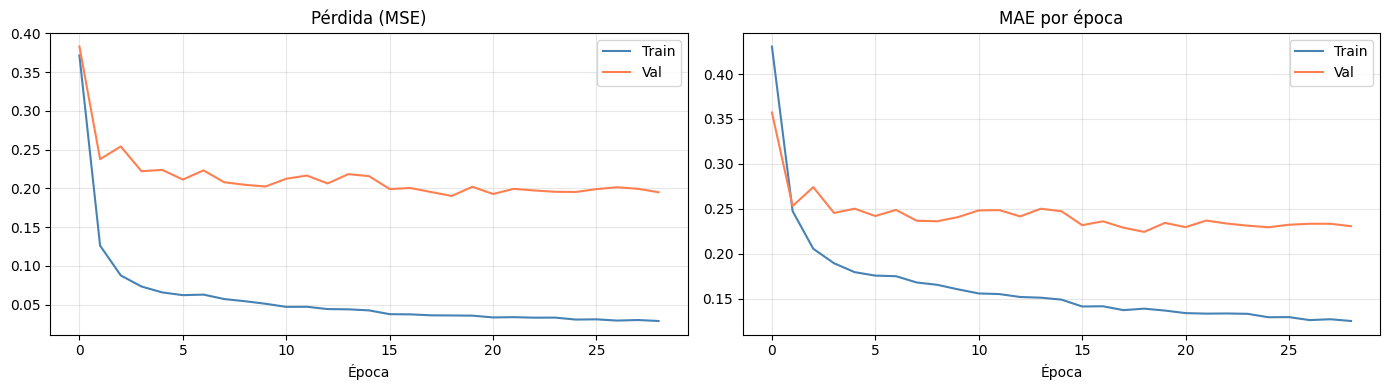

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val',   color='coral')
axes[0].set_title('Pérdida (MSE)'); axes[0].set_xlabel('Época')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val',   color='coral')
axes[1].set_title('MAE por época'); axes[1].set_xlabel('Época')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'curvas_entrenamiento.png'), dpi=150)
plt.show()


## 13. Evaluación del BiLSTM en conjunto de prueba

In [ ]:
y_pred_bilstm = bilstm.predict(X_te, verbose=0).flatten()
res_bilstm = compute_metrics(y_te, y_pred_bilstm, "BiLSTM con clima")


─────────────────────────────────────────────
  BiLSTM con clima
─────────────────────────────────────────────
  MAE   =       31.7  pasajeros
  RMSE  =       47.2  pasajeros
  MAPE  =      38.17  %
  R²    =     0.8505
─────────────────────────────────────────────


## 14. Línea base 1 — Naive (lag de 24 h)

Predice que la demanda de la hora $t$ es igual a la de $t-24$.


In [ ]:
# y_te corresponde a las muestras [N_TRAIN+N_VAL+T : ... ] del df_pilot.
# El "naive predicho" es la columna ridership_lag_24h ya normalizada
# alineada con el mismo rango de muestras.
naive_pred_norm = test_df['ridership_lag_24h'].iloc[T : T + len(y_te)].values.astype(np.float32)

res_naive = compute_metrics(y_te, naive_pred_norm, "Naive (lag 24h)")


─────────────────────────────────────────────
  Naive (lag 24h)
─────────────────────────────────────────────
  MAE   =       34.3  pasajeros
  RMSE  =       58.7  pasajeros
  MAPE  =      32.33  %
  R²    =     0.7681
─────────────────────────────────────────────


## 15. Línea base 2 — LSTM unidireccional

In [ ]:
def build_lstm(input_shape, u1=64, u2=32, dense=32, drop=0.2, lr=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(u1, return_sequences=True),
        Dropout(drop),
        LSTM(u2, return_sequences=False),
        Dropout(drop),
        Dense(dense, activation='relu'),
        Dense(1, activation='linear')
    ], name='LSTM_baseline')
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

lstm = build_lstm(input_shape=(T, X_tr.shape[2]))
lstm.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=100, batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
    verbose=0
)

y_pred_lstm = lstm.predict(X_te, verbose=0).flatten()
res_lstm = compute_metrics(y_te, y_pred_lstm, "LSTM unidireccional")


─────────────────────────────────────────────
  LSTM unidireccional
─────────────────────────────────────────────
  MAE   =       32.1  pasajeros
  RMSE  =       46.5  pasajeros
  MAPE  =      51.32  %
  R²    =     0.8550
─────────────────────────────────────────────


## 16. Ablación — BiLSTM sin variables climáticas

In [ ]:
scaler_X_nw = StandardScaler()
X_tr_nw = scaler_X_nw.fit_transform(train_df[FEAT_NO_WEATHER])
X_vl_nw = scaler_X_nw.transform(val_df[FEAT_NO_WEATHER])
X_te_nw = scaler_X_nw.transform(test_df[FEAT_NO_WEATHER])

X_tr_nw_s, y_tr_nw_s = make_sequences(X_tr_nw, y_tr_sc)
X_vl_nw_s, y_vl_nw_s = make_sequences(X_vl_nw, y_vl_sc)
X_te_nw_s, y_te_nw_s = make_sequences(X_te_nw, y_te_sc)

bilstm_nw = build_bilstm(input_shape=(T, X_tr_nw_s.shape[2]))
bilstm_nw.fit(
    X_tr_nw_s, y_tr_nw_s,
    validation_data=(X_vl_nw_s, y_vl_nw_s),
    epochs=100, batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, verbose=0)],
    verbose=0
)

y_pred_nw = bilstm_nw.predict(X_te_nw_s, verbose=0).flatten()
res_nw = compute_metrics(y_te_nw_s, y_pred_nw, "BiLSTM sin clima")


─────────────────────────────────────────────
  BiLSTM sin clima
─────────────────────────────────────────────
  MAE   =       30.4  pasajeros
  RMSE  =       46.1  pasajeros
  MAPE  =      43.02  %
  R²    =     0.8569
─────────────────────────────────────────────


## 17. Resultados comparativos y visualizaciones

In [ ]:
all_results = [res_naive, res_lstm, res_nw, res_bilstm]

summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_true', 'y_pred']}
    for r in all_results
]).set_index('label')

print("\n" + "="*55)
print("  TABLA COMPARATIVA — CONJUNTO DE PRUEBA")
print("="*55)
print(summary.to_string())
print("="*55)
summary.to_csv(os.path.join(PATH_RESULTS, 'resultados.csv'))



  TABLA COMPARATIVA — CONJUNTO DE PRUEBA
                           MAE       RMSE       MAPE        R2
label                                                         
Naive (lag 24h)      34.252845  58.745178  32.326647  0.768087
LSTM unidireccional  32.124679  46.458877  51.320724  0.854950
BiLSTM sin clima     30.383053  46.139803  43.019014  0.856936
BiLSTM con clima     31.710089  47.172881  38.168619  0.850457


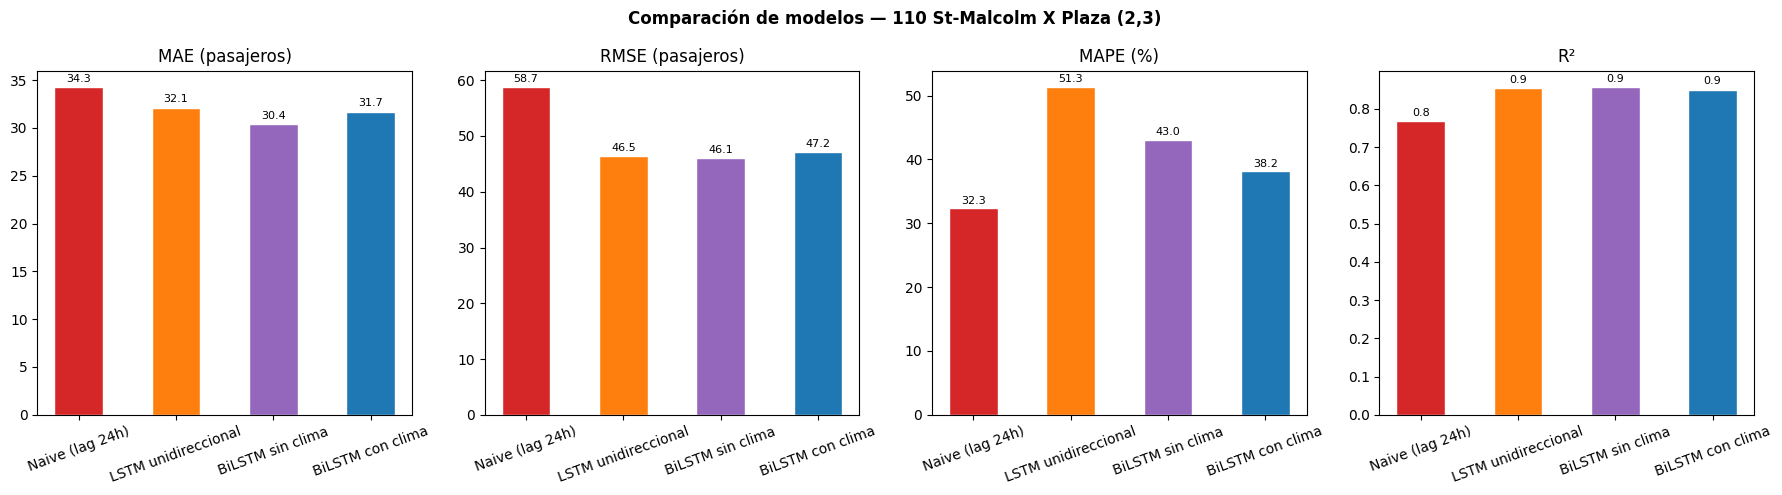

In [ ]:
# ── Barras comparativas ──────────────────────────────────────────────────
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
titles  = ['MAE (pasajeros)', 'RMSE (pasajeros)', 'MAPE (%)', 'R²']
colors  = ['#d62728', '#ff7f0e', '#9467bd', '#1f77b4']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, m, t in zip(axes, metrics, titles):
    bars = ax.bar(summary.index, summary[m], color=colors, width=0.5, edgecolor='white')
    ax.set_title(t)
    ax.tick_params(axis='x', rotation=20)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.01,
                f"{b.get_height():.1f}", ha='center', va='bottom', fontsize=8)
plt.suptitle(f'Comparación de modelos — {PILOT_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'comparacion_modelos.png'), dpi=150)
plt.show()


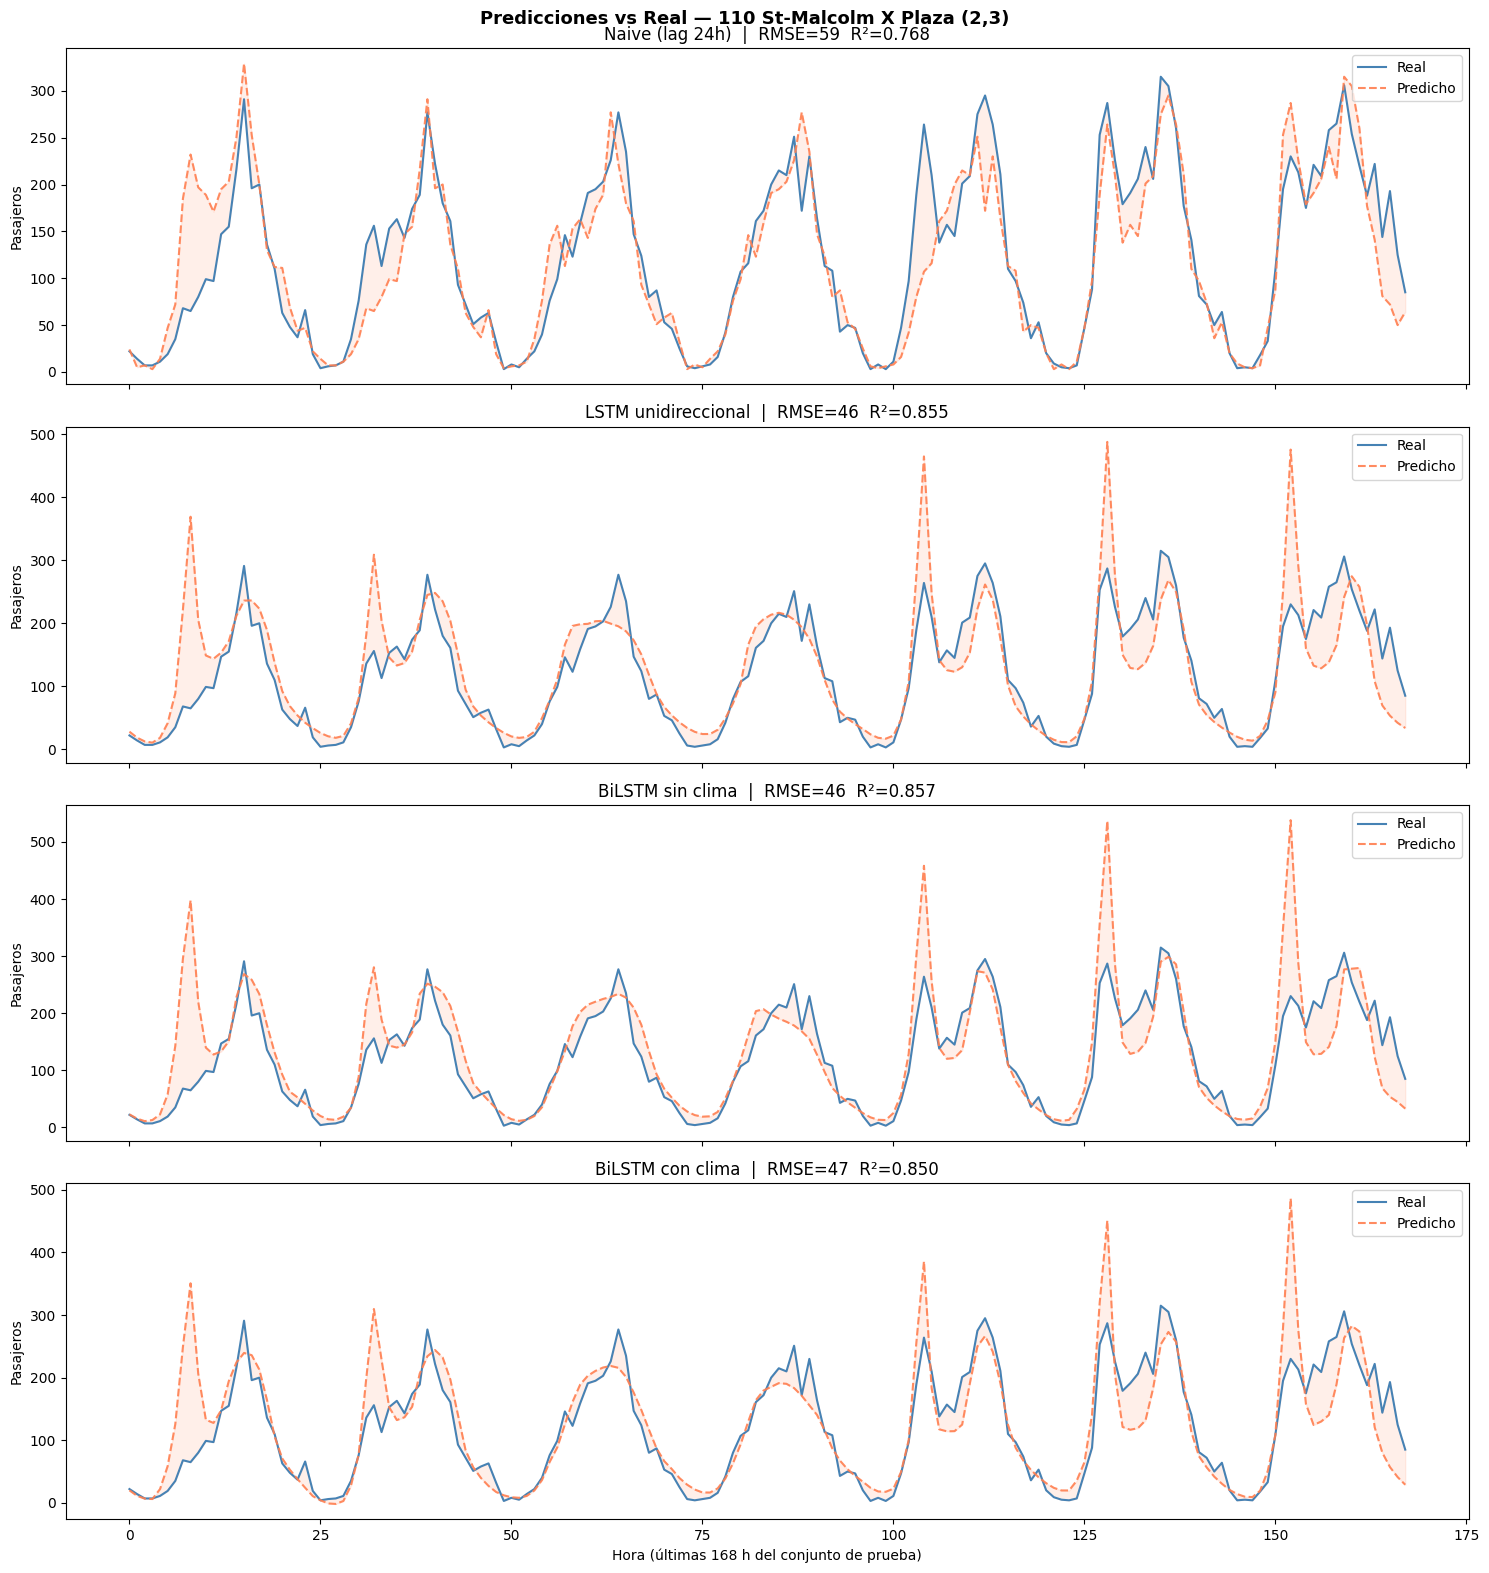

In [ ]:
# ── Predicciones vs real (últimas 168 h) ─────────────────────────────────
N_SHOW = 168
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

for ax, res in zip(axes, all_results):
    yt = res['y_true'][-N_SHOW:]
    yp = res['y_pred'][-N_SHOW:]
    ax.plot(yt, label='Real',     color='steelblue', linewidth=1.5)
    ax.plot(yp, label='Predicho', color='coral',
            linestyle='--', linewidth=1.5, alpha=0.9)
    ax.fill_between(range(len(yt)), yt, yp, alpha=0.12, color='coral')
    ax.set_title(f"{res['label']}  |  RMSE={res['RMSE']:,.0f}  R²={res['R2']:.3f}")
    ax.set_ylabel('Pasajeros')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Hora (últimas 168 h del conjunto de prueba)')
plt.suptitle(f'Predicciones vs Real — {PILOT_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'predicciones.png'), dpi=150)
plt.show()


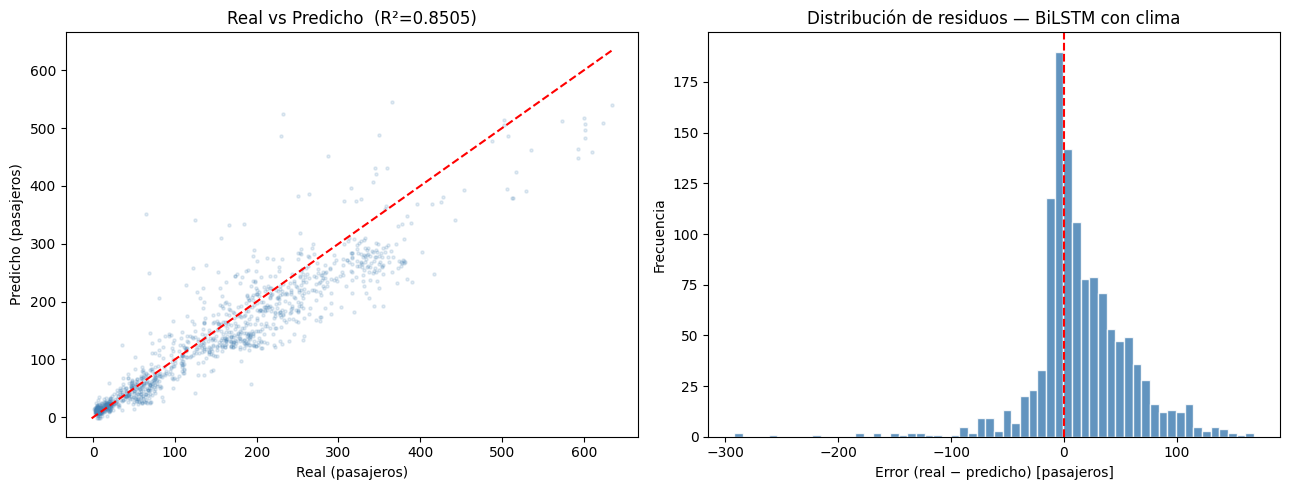

In [ ]:
# ── Scatter Real vs Predicho + residuos (BiLSTM con clima) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(res_bilstm['y_true'], res_bilstm['y_pred'],
                alpha=0.15, s=5, color='steelblue')
lim = [min(res_bilstm['y_true'].min(), res_bilstm['y_pred'].min()),
       max(res_bilstm['y_true'].max(), res_bilstm['y_pred'].max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_xlabel('Real (pasajeros)')
axes[0].set_ylabel('Predicho (pasajeros)')
axes[0].set_title(f'Real vs Predicho  (R²={res_bilstm["R2"]:.4f})')

residuos = res_bilstm['y_true'] - res_bilstm['y_pred']
axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error (real − predicho) [pasajeros]')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos — BiLSTM con clima')

plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'residuos.png'), dpi=150)
plt.show()


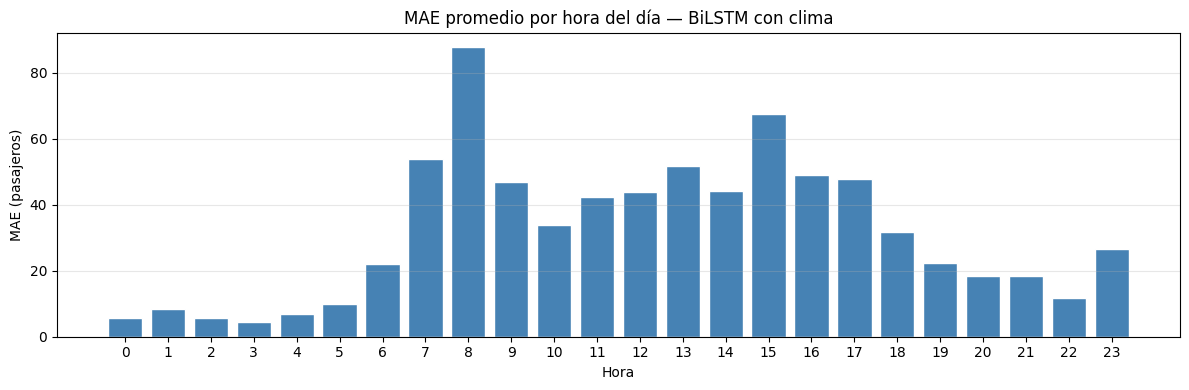

In [ ]:
# ── MAE por hora del día ─────────────────────────────────────────────────
test_dt = test_df['datetime'].iloc[T : T + len(y_te)].values
df_err = pd.DataFrame({
    'datetime' : pd.to_datetime(test_dt),
    'abs_error': np.abs(res_bilstm['y_true'] - res_bilstm['y_pred'])
})
df_err['hour'] = df_err['datetime'].dt.hour
hourly_mae = df_err.groupby('hour')['abs_error'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly_mae.index, hourly_mae.values, color='steelblue', edgecolor='white')
ax.set_title('MAE promedio por hora del día — BiLSTM con clima')
ax.set_xlabel('Hora'); ax.set_ylabel('MAE (pasajeros)')
ax.set_xticks(range(0, 24)); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PATH_RESULTS, 'mae_por_hora.png'), dpi=150)
plt.show()


## 18. Guardar artefactos en Drive

In [ ]:
bilstm.save(   os.path.join(PATH_MODELS, 'bilstm_clima.keras'))
lstm.save(     os.path.join(PATH_MODELS, 'lstm_baseline.keras'))
bilstm_nw.save(os.path.join(PATH_MODELS, 'bilstm_sin_clima.keras'))

with open(os.path.join(PATH_MODELS, 'scaler_X.pkl'), 'wb') as f:
    pickle.dump(scaler_X, f)

# Estadísticos de normalización por estación
station_stats.to_csv(os.path.join(PATH_MODELS, 'station_stats.csv'))

pd.DataFrame(history.history).to_csv(
    os.path.join(PATH_RESULTS, 'training_history.csv'), index=False)

print("Artefactos guardados:")
for p in [PATH_MODELS, PATH_RESULTS]:
    for f in sorted(os.listdir(p)):
        print(f"  {f}")


Artefactos guardados:
  bilstm_best.keras
  bilstm_clima.keras
  bilstm_sin_clima.keras
  lstm_baseline.keras
  scaler_X.pkl
  station_stats.csv
  comparacion_modelos.png
  correlacion.png
  curvas_entrenamiento.png
  eda_overview.png
  heatmap_semanal.png
  mae_por_hora.png
  predicciones.png
  residuos.png
  resultados.csv
  training_history.csv
